In [1]:
import numpy as np
import matplotlib.pyplot as plt

def leastsquares(x, y):
    n = len(x)

    sumX = np.sum(x)
    sumY = np.sum(y)
    sumX2 = np.sum(x**2)
    sumXY = np.sum(x*y)

    m = (n*sumXY - sumX*sumY) / (n*sumX2 - sumX**2)
    c = (sumY - m*sumX) / n

    return m, c

Slope: -0.069586148966621
Intercept: 0.4965821850103922


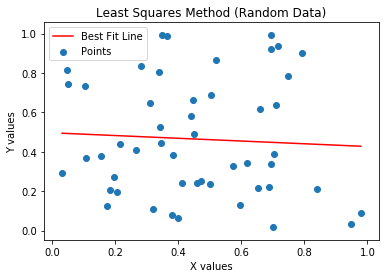

In [2]:
x = np.random.rand(50)
y = np.random.rand(50)

x_sorted = np.sort(x)

m, c = leastsquares(x_sorted, y)

print("Slope:", m)
print("Intercept:", c)

plt.scatter(x_sorted, y, label="Points")

y_pred = m*x_sorted + c

plt.plot(x_sorted, y_pred, 'r', label="Best Fit Line")

plt.title("Least Squares Method (Random Data)")
plt.xlabel("X values")
plt.ylabel("Y values")
plt.legend()
plt.show()

In [3]:
x = np.arange(0, 1.01, 0.01)

m_true = np.random.uniform(-5, 5)
b_true = np.random.uniform(-10, 10)

y = m_true*x + b_true

noise = np.random.uniform(-1, 1, len(x))
y = y + noise

In [4]:
m_fit, c_fit = leastsquares(x, y)

print("Original slope:", m_true)
print("Original intercept:", b_true)

print("Estimated slope:", m_fit)
print("Estimated intercept:", c_fit)

Original slope: -3.8169536407459126
Original intercept: 2.5005223741783578
Estimated slope: -3.697068265221884
Estimated intercept: 2.440407247061557


In [5]:
residuals = np.abs(y - (m_fit*x + c_fit))

largest_index = np.argmax(residuals)
smallest_index = np.argmin(residuals)

print("Largest residual:", residuals[largest_index], "at x =", x[largest_index])
print("Smallest residual:", residuals[smallest_index], "at x =", x[smallest_index])

Largest residual: 0.9938226363614096 at x = 0.49
Smallest residual: 0.05229452279213609 at x = 0.05


In [6]:
A = np.vstack([x, np.ones(len(x))]).T

m_numpy, c_numpy = np.linalg.lstsq(A, y, rcond=None)[0]

print("Numpy slope:", m_numpy)
print("Numpy intercept:", c_numpy)

Numpy slope: -3.697068265221887
Numpy intercept: 2.4404072470615596


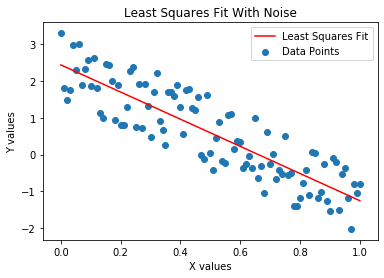

In [7]:
plt.scatter(x, y, label="Data Points")

y_pred = m_fit*x + c_fit

plt.plot(x, y_pred, 'r', label="Least Squares Fit")

plt.title("Least Squares Fit With Noise")
plt.xlabel("X values")
plt.ylabel("Y values")
plt.legend()
plt.show()